In [2]:
import warnings
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from itertools import cycle, islice
import plotly.express as px
import plotly.graph_objects as go

# set display options
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

# Research questions

- <mark>Can we identify distinct groups of artists who are enjoyed by similar listeners?</mark>

- Can we predict which songs a user is likely to add to their genre based on their listening history and similar users’ behavior?
  - Engineered fields: Song popularity (Number of times a song appears across all playlists) and Collaborative similarity index (Overlap in playlist content between users)
- Can we predict whether a song will be added to a playlist , based on the song elements (key, tempo, genre, and loudness) of the songs that already exist in the playlist?

In [3]:
df = pd.read_csv('../../data/clean_data.csv')
df.head()

,user,artist,playlist,tracks,spotify_popularity,genre,key,tempo,popularity,energy,danceability,positiveness,speechiness,liveness,acousticness,instrumentalness,good_for_party,good_for_work_study,good_for_relaxation_meditation,good_for_exercise,good_for_running,good_for_yoga_stretching,good_for_driving,good_for_social_gatherings,good_for_morning_routine,length_seconds,loudness_db_num
0,00055176fea33f6e027cd3302289378b,5 Seconds Of Summer,favs,10,0.025129,"pop,pop rock,pop punk",D Maj,134.162338,44.811688,80.545455,53.415584,45.896104,11.272727,27.863636,5.409091,0.655844,0.175325,0.000000,0.000000,0.285714,0.162338,0.0,0.038961,0.006494,0.032468,210.675325,-4.913896
1,00055176fea33f6e027cd3302289378b,Against The Current,favs,3,0.001571,"acoustic,pop rock,rock",G Maj,121.264706,37.147059,84.441176,58.529412,57.176471,5.411765,16.058824,4.205882,0.000000,0.088235,0.000000,0.000000,0.352941,0.088235,0.0,0.029412,0.000000,0.029412,199.794118,-4.070000
2,00055176fea33f6e027cd3302289378b,All Time Low,favs,8,0.030531,"alternative rock,emo,pop punk",D Maj,142.752066,38.801653,87.652893,48.074380,53.223140,7.842975,20.074380,3.694215,0.528926,0.082645,0.008264,0.000000,0.206612,0.049587,0.0,0.000000,0.000000,0.000000,202.413223,-4.211901
3,00055176fea33f6e027cd3302289378b,Austin Mahone,favs,1,0.016145,pop,B Maj,111.692308,31.871795,63.461538,67.384615,56.435897,5.846154,15.769231,18.256410,0.000000,0.153846,0.076923,0.051282,0.230769,0.025641,0.0,0.128205,0.000000,0.230769,198.230769,-5.960256
4,00055176fea33f6e027cd3302289378b,Avril Lavigne,favs,2,0.071806,"rock,pop,alternative rock",F Maj,128.726316,57.505263,79.252632,52.368421,48.052632,5.836842,23.073684,6.663158,0.363158,0.157895,0.005263,0.000000,0.242105,0.152632,0.0,0.005263,0.010526,0.021053,214.731579,-4.756263


# Preprocessing

Let's cluster this data to find similar groups

In [3]:
# separate columns by dtypes
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print('Categorical columns: ', cat_cols)
print('Numerical columns: ', num_cols)
df.isnull().sum().sum()

Categorical columns:  ['user', 'artist', 'playlist', 'genre', 'key']
Numerical columns:  ['tracks', 'spotify_popularity', 'tempo', 'popularity', 'energy', 'danceability', 'positiveness', 'speechiness', 'liveness', 'acousticness', 'instrumentalness', 'good_for_party', 'good_for_work_study', 'good_for_relaxation_meditation', 'good_for_exercise', 'good_for_running', 'good_for_yoga_stretching', 'good_for_driving', 'good_for_social_gatherings', 'good_for_morning_routine', 'length_seconds', 'loudness_db_num']


0

In [4]:
# run tf_idf for clustering (exclude id columns like user/artist)
tf_idf_cols = ['playlist', 'genre', 'key']

# create vectorizers
playlist_vectorizer = TfidfVectorizer(
    max_df=0.5,
    min_df=5,
    stop_words="english",
)
playlist_tfidf = playlist_vectorizer.fit_transform(df['playlist'])

genre_vectorizer = TfidfVectorizer(
    max_df=0.5,
    min_df=5,
    stop_words="english",
)
genre_tfidf = genre_vectorizer.fit_transform(df['genre'])

key_vectorizer = TfidfVectorizer(
    max_df=0.5,
    min_df=5,
    stop_words="english",
)
key_tfidf = key_vectorizer.fit_transform(df['key'])

## Playlist clustering

In [ ]:
# use kmeans to cluster playlists together
# tweaked n_clusters using elbow method below
playlist_kmeans = KMeans(n_clusters=35, random_state=42)
# fit the model
playlist_kmeans.fit(playlist_tfidf)
# store cluster labels in a variable
playlist_clusters = playlist_kmeans.labels_
df['playlist_cluster'] = playlist_clusters
df_playlist_cluster = df[['playlist', 'playlist_cluster']].drop_duplicates().copy()
# look at this to see if it makes sense
df_playlist_cluster

/Users/brandon/miniforge3/envs/mlenv_now/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


,playlist,playlist_cluster
0,favs,6
41,Fav songs,7
49,Sad songs,7
51,2014,29
83,Agnetha Fältskog,6
...,...,...
3026574,l a d y anthems,6
3026588,KickAss,6
3026645,natural elements,6
3026648,5:19,6


#### Playlist clustering notes
### k=35

- 0: baby
- 1: starred
- 2: free
- 3: radio
- 4: 80's
- 5: good, covers, others (this may be misc)
- 6: misc
- 7: songs
- 8: list
- 9: rock
- 10: day
- 11: library
- 12: time
- 13: playlist
- 14: work
- 15: party
- 16: country & summer
- 17: pop
- 18: new
- 19: 2012
- 20: live
- 21: hip
- 22: various artists
- 23: music
- 24: warm
- 25: deluxe
- 26: 2015
- 27: favorites
- 28: dance
- 29: 2014
- 30: smooth
- 31: hits
- 32: stuff
- 33: 2013
- 34: hip hop

In [6]:
df_playlist_cluster['playlist_cluster'].value_counts()

6     105995
22      2375
25      1424
7       1419
23      1409
20      1286
13      1251
29      1220
9       1184
33      1081
18       934
19       852
16       767
17       745
26       677
28       652
12       598
10       573
5        563
15       553
31       503
34       438
32       394
8        392
14       231
0        223
4        212
27       211
2        115
30        76
11        44
3         37
24        35
21        29
1         10
Name: playlist_cluster, dtype: int64

In [ ]:
# commenting out due to large runtime; cluster analysis recorded in notes
# # optimize clustering - playlist
# # find optimal k to use for grouping (hopefully get that 0 cluster down)
# inertia = []

# # we'll go up to 40 clusters
# upper = 40

# # loop through, try every k value from 2-20
# for k in range(2, upper):
#     kmeans = KMeans(n_clusters=k, random_state=0)
#     kmeans.fit(playlist_tfidf)
#     inertia.append(kmeans.inertia_)

In [8]:
# # elbow method to find optimal k
# fig = plt.figure(figsize=(10, 6)) 
# plt.plot(range(2, upper), inertia, marker='o')
# plt.title('Elbow Method for Optimal k')
# plt.xlabel('Number of Clusters (k)')
# plt.ylabel('Inertia (Sum of Squared Distances)')
# plt.xticks(range(2, upper))
# plt.show()

In [9]:
df.head()

,user,artist,playlist,tracks,spotify_popularity,genre,key,tempo,popularity,energy,...,good_for_relaxation_meditation,good_for_exercise,good_for_running,good_for_yoga_stretching,good_for_driving,good_for_social_gatherings,good_for_morning_routine,length_seconds,loudness_db_num,playlist_cluster
0,00055176fea33f6e027cd3302289378b,5 Seconds Of Summer,favs,10,0.025129,"pop,pop rock,pop punk",D Maj,134.162338,44.811688,80.545455,...,0.000000,0.285714,0.162338,0.0,0.038961,0.006494,0.032468,210.675325,-4.913896,6
1,00055176fea33f6e027cd3302289378b,Against The Current,favs,3,0.001571,"acoustic,pop rock,rock",G Maj,121.264706,37.147059,84.441176,...,0.000000,0.352941,0.088235,0.0,0.029412,0.000000,0.029412,199.794118,-4.070000,6
2,00055176fea33f6e027cd3302289378b,All Time Low,favs,8,0.030531,"alternative rock,emo,pop punk",D Maj,142.752066,38.801653,87.652893,...,0.000000,0.206612,0.049587,0.0,0.000000,0.000000,0.000000,202.413223,-4.211901,6
3,00055176fea33f6e027cd3302289378b,Austin Mahone,favs,1,0.016145,pop,B Maj,111.692308,31.871795,63.461538,...,0.051282,0.230769,0.025641,0.0,0.128205,0.000000,0.230769,198.230769,-5.960256,6
4,00055176fea33f6e027cd3302289378b,Avril Lavigne,favs,2,0.071806,"rock,pop,alternative rock",F Maj,128.726316,57.505263,79.252632,...,0.000000,0.242105,0.152632,0.0,0.005263,0.010526,0.021053,214.731579,-4.756263,6


In [10]:
# make sure you didn't do anything wrong
df.isnull().sum().sum()

0

## Genre clustering

In [11]:
# use kmeans to cluster genres together
genre_k = 12
# tweaked n_clusters using elbow method below
genre_kmeans = KMeans(n_clusters=genre_k, random_state=42)
# fit the model
genre_kmeans.fit(genre_tfidf)
# store cluster labels in a variable
genre_clusters = genre_kmeans.labels_
df['genre_cluster'] = genre_clusters
df_genre_cluster = df[['genre', 'genre_cluster']].drop_duplicates().copy()
# look at this to see if it makes sense
df_genre_cluster

/Users/brandon/miniforge3/envs/mlenv_now/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


,genre,genre_cluster
0,"pop,pop rock,pop punk",5
1,"acoustic,pop rock,rock",0
2,"alternative rock,emo,pop punk",9
3,pop,5
4,"rock,pop,alternative rock",0
...,...,...
2919402,"progressive rock,metal,progressive metal",9
2931633,"j-pop,indie,pop",8
2960338,"punk,pop rock",5
2973903,"rock,hip-hop,reggae",1


### Genre clustering notes

#### k = 12

- 0: rock
- 1: hip-hop
- 2: electronic
- 3: country
- 4: soul
- 5: pop
- 6: synth
- 7: folk
- 8: indie
- 9: misc / rock / metal / punk
- 10: electropop
- 11: jazz

In [12]:
df_genre_cluster['genre_cluster'].value_counts()

9     967
0     359
2     240
8     215
11    129
7     119
4     115
1     101
5      91
6      82
10     81
3      80
Name: genre_cluster, dtype: int64

In [ ]:
# # TODO: commenting out due to large runtime; cluster analysis recorded in notes
# # optimize clustering - genre
# # find optimal k to use for grouping (hopefully get that 0 cluster down)
# inertia = []

# # we'll go up to 20 clusters
# upper = 20

# # loop through, try every k value from 2-20
# for k in range(2, upper):
#     kmeans = KMeans(n_clusters=k, random_state=0)
#     kmeans.fit(genre_tfidf)
#     inertia.append(kmeans.inertia_)

In [ ]:
# # TODO: elbow method to find optimal k (slow, commented out until notebook finalized)
# fig = plt.figure(figsize=(10, 6)) 
# plt.plot(range(2, upper), inertia, marker='o')
# plt.title('Elbow Method for Optimal k')
# plt.xlabel('Number of Clusters (k)')
# plt.ylabel('Inertia (Sum of Squared Distances)')
# plt.xticks(range(2, upper))
# plt.show()

In [15]:
# see if key needs to be clustered or one-hot, etc
# with 24 items, go with label encoding or target encoding (below)
df['key'].drop_duplicates()

0       D Maj
1       G Maj
3       B Maj
4       F Maj
5      F# Maj
6       C Maj
8      C# min
12     D# Maj
13     G# Maj
14     D# min
17      A Maj
19      F min
21     A# Maj
23      E min
30      E Maj
32      A min
33      B min
34     C# Maj
37      G min
43     F# min
44      D min
45     G# min
58     A# min
176     C min
Name: key, dtype: object

# Preprocess data for model

In [ ]:
# make categorical cluster dictionary from markdown notes
genre_cluster_dict = {
    0: 'rock',
    1: 'hip-hop',
    2: 'electronic',
    3: 'country',
    4: 'soul',
    5: 'pop',
    6: 'synth',
    7: 'folk',
    8: 'indie',
    9: 'misc',
    10: 'electropop',
    11: 'jazz'
}

playlist_cluster_dict = {
    0: 'baby',
    1: 'starred',
    2: 'free',
    3: 'radio',
    4: "80's",
    5: 'good, covers',
    6: 'misc',
    7: 'songs',
    8: 'list',
    9: 'rock',
    10: 'day',
    11: 'library',
    12: 'time',
    13: 'playlist',
    14: 'work',
    15: 'party',
    16: 'country & summer',
    17: 'pop',
    18: 'new',
    19: '2012',
    20: 'live',
    21: 'hip',
    22: 'various artists',
    23: 'music',
    24: 'warm',
    25: 'deluxe',
    26: '2015',
    27: 'favorites',
    28: 'dance',
    29: '2014',
    30: 'smooth',
    31: 'hits',
    32: 'stuff',
    33: '2013',
    34: 'hip hop'
}

# drop categoricals that have already been converted 
df = df.drop(['playlist', 'genre'], axis=1)

In [19]:
# convert key to numerical and keep dictionary
def label_encode(df, column):
    # encodes with label encoding, creates a dict, drops orig field
    le = LabelEncoder()
    encode_col = f'encoded_{column}'
    df[encode_col] = le.fit_transform(df[column])
    encode_dict = dict(zip(df[encode_col], df[column]))
    # drop key column
    df = df.drop(column, axis=1)
    return df, encode_dict
df, key_dict = label_encode(df, 'key')

In [20]:
# handle user and artist columns
df, user_dict = label_encode(df, 'user')
df, artist_dict = label_encode(df, 'artist')

In [21]:
# scale columns
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

# Print the first few rows of the scaled DataFrame
df_scaled.head()

,tracks,spotify_popularity,tempo,popularity,energy,danceability,positiveness,speechiness,liveness,acousticness,...,good_for_driving,good_for_social_gatherings,good_for_morning_routine,length_seconds,loudness_db_num,playlist_cluster,genre_cluster,encoded_key,encoded_user,encoded_artist
0,0.671333,-0.509285,1.001246,0.738532,0.965072,-0.249899,-0.203578,0.595331,1.088437,-0.882902,...,-0.077897,-0.148138,-0.304741,-0.507071,1.075488,-0.324883,0.163329,0.054619,-1.72247,-1.727603
1,-0.007288,-0.920003,0.011918,0.126424,1.199092,0.186841,0.487413,-0.344771,-0.427640,-0.937822,...,-0.176448,-0.256234,-0.328255,-0.701726,1.364636,-0.324883,-1.179070,1.541367,-1.72247,-1.674383
2,0.477441,-0.415093,1.660131,0.258562,1.392023,-0.706057,0.245248,0.045197,0.088073,-0.961177,...,-0.479986,-0.256234,-0.554577,-0.654872,1.316016,-0.324883,1.237248,0.054619,-1.72247,-1.634536
3,-0.201179,-0.665905,-0.722344,-0.294866,-0.061175,0.943107,0.442049,-0.275094,-0.464832,-0.296492,...,0.843129,-0.256234,1.221178,-0.729692,0.716968,-0.324883,0.163329,-0.837430,-1.72247,-1.523320
4,-0.104234,0.304484,0.584270,1.752258,0.887411,-0.339330,-0.071477,-0.276588,0.473270,-0.825661,...,-0.425669,-0.081005,-0.392578,-0.434508,1.129499,-0.324883,-1.179070,0.946668,-1.72247,-1.517452


In [ ]:
# create optimized k-means clustering model
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_scaled['cluster'] = kmeans.fit_predict(df_scaled)

In [ ]:
# add clusters to original df for analysis/visualization
df['cluster'] = df_scaled['cluster']
# remove good_for_ from the start of columns to make charts more readable
df = df.rename(columns=lambda x: x.replace('good_for_', ''))

In [26]:
# create a bunch of radar plots to find most distinguishable differences
def radar_plot(df, cols, range=100):
      df_graph = df[cols].copy()

      df_graph.iloc[0]
      df_graph.iloc[0].index
      df_graph.iloc[0].values

      categories = df_graph.iloc[0].index

      fig = go.Figure()

      # cluster 0
      fig.add_trace(go.Scatterpolar(
            r=df_graph.iloc[0].values,
            theta=categories,
            name='Cluster 0'
      ))

      fig.add_trace(go.Scatterpolar(
            r=df_graph.iloc[1].values,
            theta=categories,
            name='Cluster 1'
      ))

      fig.add_trace(go.Scatterpolar(
            r=df_graph.iloc[2].values,
            theta=categories,
            name='Cluster 2'
      ))

      fig.add_trace(go.Scatterpolar(
            r=df_graph.iloc[3].values,
            theta=categories,
            name='Cluster 3'
      ))
      # colorblind palette
      color_palette = {'Cluster 3': "#0072B2", 
                       'Cluster 0': "#E69F00",
                       'Cluster 2': "#800080",
                       'Cluster 1': "#009E73"}

      for group, color in color_palette.items():
            fig.update_traces(
                  line=dict(color=color),
                  selector=dict(name=group))

      fig.update_layout(
            polar=dict(
                  radialaxis=dict(
                        visible=False,
                        range=[0, range]
            )),

            showlegend=True,
            title='Music Qualities by Cluster',
            legend=dict(
                  x=-0.07,
                  y=1.00,
            )
      )
      return fig

In [27]:
# make radar charts
df_grouped_med = df.groupby('cluster').median()

# use the most distinct values from df_grouped_med
focus_cols_best = ['popularity', 'energy', 'danceability', 'positiveness', 'acousticness']
radar_plot(df_grouped_med, focus_cols_best)

In [55]:
df_grouped_med

,tracks,spotify_popularity,tempo,popularity,energy,danceability,positiveness,speechiness,liveness,acousticness,instrumentalness,party,work_study,relaxation_meditation,exercise,running,yoga_stretching,driving,social_gatherings,morning_routine,length_seconds,loudness_db_num,playlist_cluster,genre_cluster,encoded_key,encoded_user,encoded_artist,"length_minutes, seconds"
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,1.0,0.026322,115.318182,34.151515,62.393939,66.402985,59.111111,7.02069,18.000000,20.662651,1.000000,0.000000,0.000000,0.000000,0.126482,0.010309,0.000000,0.076923,0.0,0.092715,231.710526,-8.000000,6.0,4.0,8.0,7694.0,12514.0,3
1,1.0,0.024752,112.921875,31.192308,38.388889,51.314815,37.142857,4.25000,15.363636,62.941176,3.333333,0.000000,0.326446,0.119048,0.015385,0.000000,0.080645,0.000000,0.0,0.000000,226.833333,-11.893333,6.0,6.0,8.0,7651.0,11836.0,3
2,1.0,0.033924,123.733333,33.000000,70.000000,49.138462,42.904762,5.00000,19.333333,15.800000,4.701183,0.009174,0.018349,0.000000,0.111111,0.008584,0.000000,0.000000,0.0,0.022059,241.476923,-7.188333,6.0,3.0,8.0,7610.0,14217.0,4
3,1.0,0.053776,126.473684,41.857143,75.355932,62.933333,56.796296,6.17500,18.622378,9.552632,1.305263,0.222222,0.000000,0.000000,0.500000,0.076923,0.000000,0.000000,0.0,0.040268,220.308411,-5.903875,6.0,4.0,8.0,7600.0,11781.0,3


## Artists by Music Qualities

### Cluster 0
Favors artists in the dance genre, with sounds that are more positive

Artist examples:
- Sean Paul (2005)
- KAYTRANADA (2025)
- Wham! (1984)
- Gwen Stefani (2016)
- Michael Jackson (1987)

### Cluster 1
Likes accoustic music, lower energy, less-danceable artists, and is the least attracted to popular songs

Artist examples:
- Ray Charles (1960)
- The Everly Brothers (1964)
- Bon Iver (2009)
- Regina Spektor (2006)
- The Lumineers (2016)

### Cluster 2
Second highest in energy, yet lowest in danceability

Artist examples:
- The Killers (2004)
- Yeah Yeah Yeahs (2007)
- M83 (2003)
- Aerosmith (1975)
- alt-J (2022)

### Cluster 3
Loves popular music and high energy, as well as danceable, positive songs

Artist examples:
- Imagine Dragons (2012)
- 50 Cent (2003)
- Katy Perry (2017)
- Taylor Swift (2022)
- Maroon 5 (2010)

In [94]:
# sample artists that define each cluster
# cluster 0
print("cluster 0\n", df[df['cluster'] == 0].sample(5)['encoded_artist'].map(artist_dict))
# cluster 1
print("cluster 1\n", df[df['cluster'] == 1].sample(5)['encoded_artist'].map(artist_dict))
# cluster 2
print("cluster 2\n", df[df['cluster'] == 2].sample(5)['encoded_artist'].map(artist_dict))
# cluster 3
print("cluster 3\n", df[df['cluster'] == 3].sample(5)['encoded_artist'].map(artist_dict))


cluster 0
 459431      Martin Solveig
1596301    Michael Jackson
1458399          Specifics
1964951      Stevie Wonder
2401925      Fontella Bass
Name: encoded_artist, dtype: object
cluster 1
 1924990           Portland
1588196            Chicane
2778823    Christina Perri
934574     Waylon Jennings
1787722            M. Ward
Name: encoded_artist, dtype: object
cluster 2
 1057487           Miles Kane
2656859                alt-J
2100741      Plain White T's
1706740    The Front Bottoms
2564353               Loreen
Name: encoded_artist, dtype: object
cluster 3
 1583387    Two Door Cinema Club
2568638          Robin Williams
1516471             The Strokes
1705379         Vampire Weekend
1558759                Maroon 5
Name: encoded_artist, dtype: object


In [29]:
# create a bunch of radar plots to find most distinguishable differences
def radar_plot_filled(df, cols, title, range=100):
      df_graph = df[cols].copy()

      df_graph.iloc[0]
      df_graph.iloc[0].index
      df_graph.iloc[0].values

      categories = df_graph.iloc[0].index

      # colors = px.colors.viridis

      fig = go.Figure()

      # cluster 0
      fig.add_trace(go.Scatterpolar(
            r=df_graph.iloc[0].values,
            theta=categories,
            name='Cluster 0',
            fill='toself'
      ))

      fig.add_trace(go.Scatterpolar(
            r=df_graph.iloc[1].values,
            theta=categories,
            name='Cluster 1',
            fill='toself'
      ))

      fig.add_trace(go.Scatterpolar(
            r=df_graph.iloc[2].values,
            theta=categories,
            name='Cluster 2',
            fill='toself'
      ))

      fig.add_trace(go.Scatterpolar(
            r=df_graph.iloc[3].values,
            theta=categories,
            name='Cluster 3',
            fill='toself'
      ))
      # colorblind palette
      color_palette = {'Cluster 3': "#0072B2", 
                       'Cluster 0': "#E69F00",
                       'Cluster 2': "#800080",
                       'Cluster 1': "#009E73"}

      for group, color in color_palette.items():
            fig.update_traces(
                  line=dict(color=color),
                  selector=dict(name=group))

      fig.update_layout(
            polar=dict(
                  radialaxis=dict(
                        visible=False,
                        range=[0, range]
            )),

            showlegend=True,
            title=title,
            legend=dict(
                  x=-0.07,
                  y=1.00,
            )
      )
      return fig

In [31]:
# good for plots
good_cols = ['yoga_stretching', 'driving', 'morning_routine', 
             'party', 'work_study', 'relaxation_meditation']
radar_plot_filled(df_grouped_med, good_cols,'Good for... Music by Cluster', .4)

In [128]:
# sample artists that define each cluster, focus on highlighted traits here
# cluster 0
print("cluster 0\n", df[(df['cluster'] == 0) &
                        (df['morning_routine'] > 0.09) &
                        (df['driving'] > 0.07)].sample(5)['encoded_artist'].map(artist_dict))
# cluster 1
print("cluster 1\n", df[(df['cluster'] == 1) &
                        (df['work_study'] > 0.32) &
                        (df['relaxation_meditation'] > 0.11) &
                        (df['yoga_stretching'] > 0.08)].sample(5)['encoded_artist'].map(artist_dict))
# cluster 2
print("cluster 2\n", df[(df['cluster'] == 2) &
                        (df['morning_routine'] < 0.023) &
                        (df['work_study'] < 0.19)].sample(5)['encoded_artist'].map(artist_dict))
# cluster 3
print("cluster 3\n", df[(df['cluster'] == 3) &
                        (df['party'] > 0.22) &
                        (df['morning_routine'] < 0.041)].sample(5)['encoded_artist'].map(artist_dict))


cluster 0
 54996                  Usher
2813487           Kris Kross
2121555    Sorcha Richardson
1176608                Uffie
254510                   Guy
Name: encoded_artist, dtype: object
cluster 1
 300626      Bobby McFerrin
208794     Louis Armstrong
1855078       The Penguins
555272       Roberta Flack
238678        Bill Withers
Name: encoded_artist, dtype: object
cluster 2
 1837122       Dave Brubeck
937481     Letters To Cleo
1178292          blink-182
585611                Muse
272693              Enigma
Name: encoded_artist, dtype: object
cluster 3
 224766                   Double You
469434                 Ricky Martin
779654                  Bag Raiders
3805                  Martin Garrix
578947    The Asteroids Galaxy Tour
Name: encoded_artist, dtype: object


## Artists by Good for...

### Cluster 0
Listens to artists that are good for routine - either in the morning or while driving

Artist examples:
- Ratatat (2006)
- Ciara (2025)
- Steely Dan (1977)
- will.i.am (2008)
- Madonna (1989)

### Cluster 1
Listens to artists that compliment studying, relaxation, and yoga

Artist examples:
- Cat Power (1998)
- James Taylor (1970)
- The Cinematic Orchestra (1994)
- Perrin Lamb (2012)
- Keren Ann (2000)

### Cluster 2
Defined by artists with small measures of morning routine and work study qualities

Artist examples:
- Mazzy Star (1993)
- The Hives (2004)
- Beach House (2025)
- Phish (1996)
- Red Hot Chili Peppers (1999)

### Cluster 3
Listens to music that is good for parties, and a little bit good for morning routine

Artist examples:
- La Bouche (1995)
- Flo Rida (2015)
- Purity Ring (2012)
- Lil Wayne (2020)
- Ricky Martin (1999)

<AxesSubplot:title={'center':'Song Tempo (BPM)'}, xlabel='cluster'>

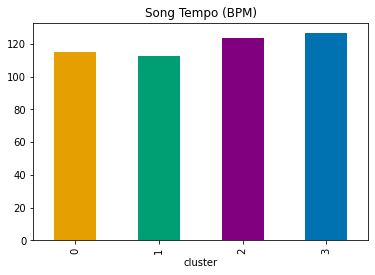

In [ ]:
# bar plots
colors = {'Cluster 3': '#0072B2',
          'Cluster 0': '#E69F00',
          'Cluster 2': '#800080',
          'Cluster 1': '#009E73'}
my_colors = list(islice(cycle(['#E69F00', '#009E73', '#800080','#0072B2']), 
                        None, 
                        len(df)))
df_grouped_med['tempo'].plot(kind='bar', title='Song Tempo (BPM)', color=my_colors)

<AxesSubplot:title={'center':'Song Length (seconds)'}, xlabel='cluster'>

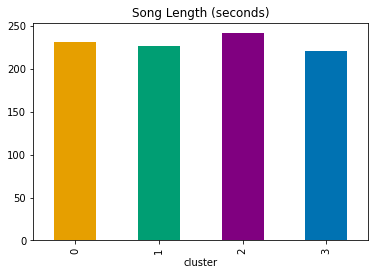

In [44]:
df_grouped_med['length_seconds'].plot(kind='bar', 
                                      title='Song Length (seconds)', 
                                      color=my_colors)

In [51]:
# Convert seconds to minutes for slides
print(df_grouped_med['length_seconds'] / 60)
print(.78 * 60)
# around 3 minutes, 45 seconds

cluster
0    3.861842
1    3.780556
2    4.024615
3    3.671807
Name: length_seconds, dtype: float64
46.800000000000004


In [34]:
focus_cols_6 = ['loudness_db_num', 'spotify_popularity']